# Sales Forecasting & Demand Intelligence System

## Name: Yash Lahase

### Project Objective

The objective of this project is to analyze historical sales data and build a machine learning system capable of forecasting future product demand. The project also identifies unusual sales patterns, segments products according to demand, and presents all insights through an interactive dashboard that can assist business managers in making inventory decisions.

---

In [1]:
# Import libraries

# Data Handling
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Date & Time
import datetime

# Machine Learning
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest

# Forecasting
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

# Ignore Warnings
import warnings
warnings.filterwarnings("ignore")

# Create folder for charts
import os
os.makedirs("charts", exist_ok=True)

print("Libraries Imported Successfully!")

Libraries Imported Successfully!


# Task 1 – Data Loading & Deep Exploration

The first step is to load the dataset and understand its structure. Before building forecasting models, it is important to verify that the dataset is clean, complete, and correctly formatted.

In [4]:
# Load Dataset
df = pd.read_csv("train.csv")

# Display first 10 rows
df.head(10)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680
5,6,CA-2015-115812,09/06/2015,14/06/2015,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032.0,West,FUR-FU-10001487,Furniture,Furnishings,Eldon Expressions Wood and Plastic Desk Access...,48.8600
6,7,CA-2015-115812,09/06/2015,14/06/2015,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032.0,West,OFF-AR-10002833,Office Supplies,Art,Newell 322,7.2800
7,8,CA-2015-115812,09/06/2015,14/06/2015,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032.0,West,TEC-PH-10002275,Technology,Phones,Mitel 5320 IP Phone VoIP phone,907.1520
8,9,CA-2015-115812,09/06/2015,14/06/2015,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032.0,West,OFF-BI-10003910,Office Supplies,Binders,DXL Angle-View Binders with Locking Rings by S...,18.5040
9,10,CA-2015-115812,09/06/2015,14/06/2015,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032.0,West,OFF-AP-10002892,Office Supplies,Appliances,Belkin F5C206VTEL 6 Outlet Surge,114.9000


In [5]:
# Number of Rows and Columns
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

Rows : 9800
Columns : 18


In [6]:
# Dataset Information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

In [7]:
# Check Data Types
df.dtypes

Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code      float64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
dtype: object

In [10]:
# Missing Values
df.isnull().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64

In [9]:
# Duplicate Records
print("Duplicate Rows :", df.duplicated().sum())

Duplicate Rows : 0


### Observation

The dataset was successfully loaded into Pandas. At this stage, we examined the number of records, checked the data types of each column, identified missing values, and verified whether duplicate records were present. These checks ensure that the dataset is suitable for further analysis.

In [12]:
# Convert Date Columns into Datetime
df["Order Date"] = pd.to_datetime(df["Order Date"], dayfirst=True)
df["Ship Date"] = pd.to_datetime(df["Ship Date"], dayfirst=True)
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [13]:
print(df["Order Date"].dtype)
print(df["Ship Date"].dtype)

datetime64[ns]
datetime64[ns]


## Extract Time Features

Time-series forecasting relies heavily on date-related information. Therefore, useful features such as year, month, quarter, week number, season, and day of the week are extracted from the order date.

In [14]:
# Extract Date Features
df["Year"] = df["Order Date"].dt.year
df["Month"] = df["Order Date"].dt.month
df["Month Name"] = df["Order Date"].dt.month_name()
df["Quarter"] = df["Order Date"].dt.quarter
df["Week"] = df["Order Date"].dt.isocalendar().week
df["Day"] = df["Order Date"].dt.day_name()

In [16]:
# Function to Identify Season
def get_season(month):
    if month in [12,1,2]:
        return "Winter"
    elif month in [3,4,5]:
        return "Summer"
    elif month in [6,7,8]:
        return "Monsoon"
    else:
        return "Autumn"
df["Season"] = df["Month"].apply(get_season)
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Sub-Category,Product Name,Sales,Year,Month,Month Name,Quarter,Week,Day,Season
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Bookcases,Bush Somerset Collection Bookcase,261.9600,2017,11,November,4,45,Wednesday,Autumn
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,2017,11,November,4,45,Wednesday,Autumn
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2017,6,June,2,24,Monday,Monsoon
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,2016,10,October,4,41,Tuesday,Autumn
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Storage,Eldon Fold 'N Roll Cart System,22.3680,2016,10,October,4,41,Tuesday,Autumn


In [17]:
# Calculate Shipping Time
df["Shipping Days"] = (
    df["Ship Date"] - df["Order Date"]
).dt.days
df[["Order Date","Ship Date","Shipping Days"]].head()

,Order Date,Ship Date,Shipping Days
0,2017-11-08,2017-11-11,3
1,2017-11-08,2017-11-11,3
2,2017-06-12,2017-06-16,4
3,2016-10-11,2016-10-18,7
4,2016-10-11,2016-10-18,7


### Observation

Additional features were created from the Order Date column to make time-series analysis easier. Shipping time was also calculated because delivery speed may influence customer satisfaction and operational performance.

In [18]:
# Daily Sales
daily_sales = df.groupby("Order Date")["Sales"].sum()
daily_sales.head()

Order Date
2015-01-03      16.448
2015-01-04     288.060
2015-01-05      19.536
2015-01-06    4407.100
2015-01-07      87.158
Name: Sales, dtype: float64

In [19]:
# Weekly Sales
weekly_sales = df.groupby(
    pd.Grouper(
        key="Order Date",
        freq="W"
    )
)["Sales"].sum()
weekly_sales.head()

Order Date
2015-01-04     304.508
2015-01-11    4619.108
2015-01-18    4130.533
2015-01-25    3092.544
2015-02-01    2527.914
Freq: W-SUN, Name: Sales, dtype: float64

The sales data has now been aggregated into daily, weekly, and monthly intervals. These different levels of aggregation will be useful because some forecasting models perform better with monthly data, while anomaly detection often benefits from weekly data.

# Business Questions

After preparing the dataset, the next step is to answer a few important business questions. These insights help us understand sales performance before building forecasting models.

In [20]:
# Total Sales by Category
category_sales = df.groupby("Category")["Sales"].sum().sort_values(ascending=False)
category_sales

Category
Technology         827455.8730
Furniture          728658.5757
Office Supplies    705422.3340
Name: Sales, dtype: float64

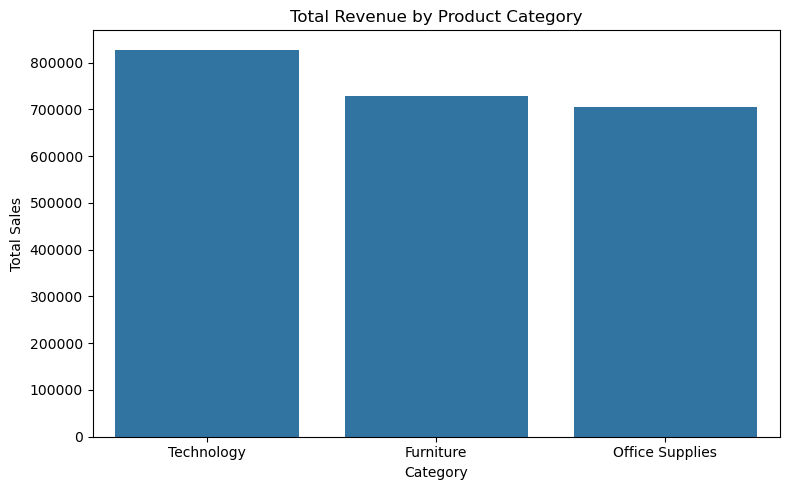

In [21]:
plt.figure(figsize=(8,5))
sns.barplot(
    x=category_sales.index,
    y=category_sales.values
)
plt.title("Total Revenue by Product Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.tight_layout()
plt.savefig("charts/category_sales.png")
plt.show()

### Observation

The chart above shows which product category contributes the highest revenue. This information helps businesses understand where most of their income is generated and where future inventory planning should focus.

In [22]:
# Sales by Region and Year
region_sales = df.groupby(["Year","Region"])["Sales"].sum().reset_index()
region_sales.head()

,Year,Region,Sales
0,2015,Central,102920.5206
1,2015,East,127652.8190
2,2015,South,103374.9055
3,2015,West,145907.9630
4,2016,Central,102425.1724


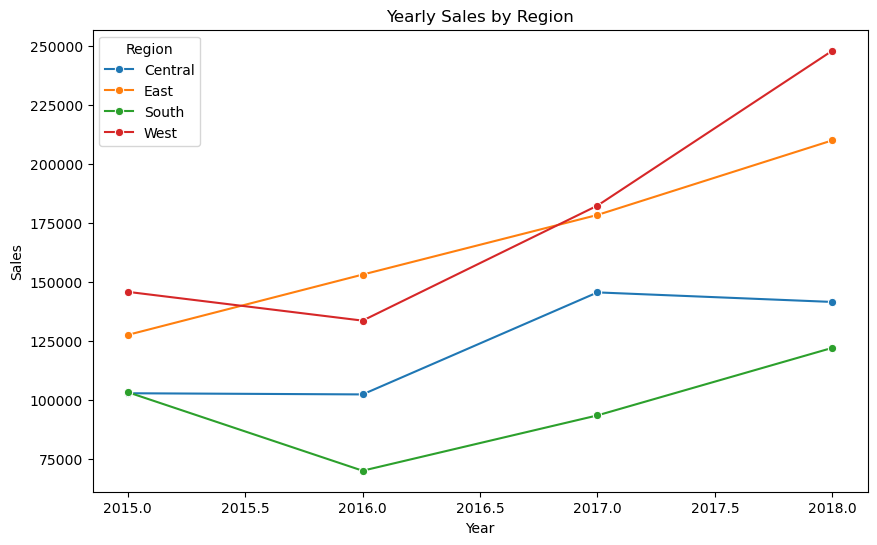

In [23]:
plt.figure(figsize=(10,6))
sns.lineplot(
    data=region_sales,
    x="Year",
    y="Sales",
    hue="Region",
    marker="o"
)
plt.title("Yearly Sales by Region")
plt.savefig("charts/region_growth.png")
plt.show()

### Observation
The region with the smoothest upward trend can be considered the most consistent performer. Consistent growth indicates stable customer demand over time.

In [24]:
# Average Shipping Days
average_shipping = df["Shipping Days"].mean()
print("Average Shipping Time :", round(average_shipping,2),"Days")

Average Shipping Time : 3.96 Days


In [25]:
shipping_region = df.groupby("Region")["Shipping Days"].mean()
shipping_region

Region
Central    4.065876
East       3.910233
South      3.961202
West       3.930255
Name: Shipping Days, dtype: float64

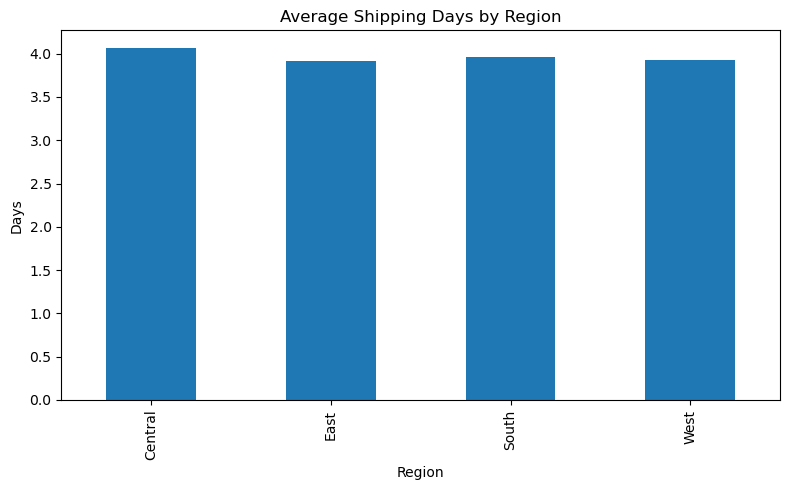

In [26]:
plt.figure(figsize=(8,5))
shipping_region.plot(kind="bar")
plt.title("Average Shipping Days by Region")
plt.ylabel("Days")
plt.tight_layout()
plt.savefig("charts/shipping_days_region.png")
plt.show()

### Observation

Different regions may have different delivery times due to transportation distance, warehouse availability, and logistics efficiency.

In [27]:
monthly_pattern = df.groupby(["Year","Month"])["Sales"].sum().reset_index()
monthly_pattern.head()

,Year,Month,Sales
0,2015,1,14205.707
1,2015,2,4519.892
2,2015,3,55205.797
3,2015,4,27906.855
4,2015,5,23644.303


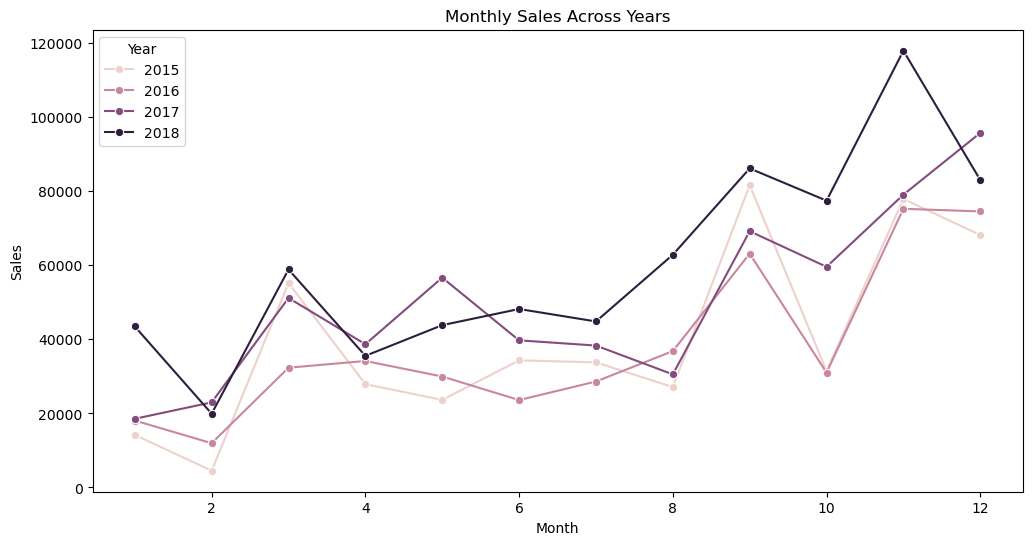

In [28]:
plt.figure(figsize=(12,6))
sns.lineplot(
    data=monthly_pattern,
    x="Month",
    y="Sales",
    hue="Year",
    marker="o"
)
plt.title("Monthly Sales Across Years")
plt.savefig("charts/monthly_pattern.png")
plt.show()

### Observation

If certain months show higher sales every year, this indicates seasonality. Retail businesses often experience increased sales during holiday and festival periods.

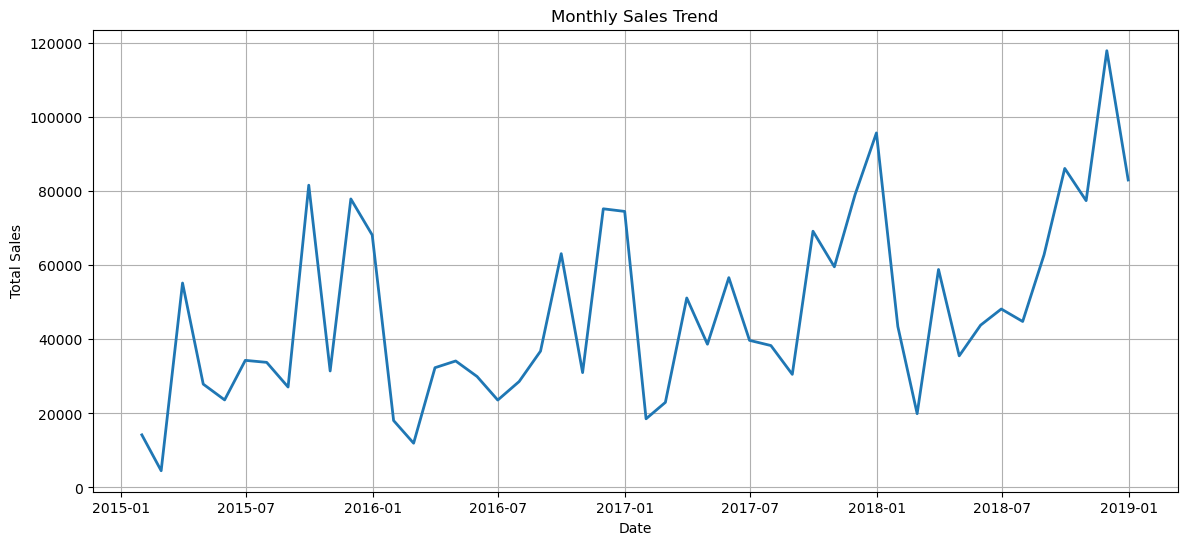

In [34]:
# Create Monthly Sales Time Series
monthly_sales = (
    df.groupby(pd.Grouper(key="Order Date", freq="ME"))["Sales"]
      .sum()
)
monthly_sales.head()
plt.figure(figsize=(14,6))
plt.plot(monthly_sales.index, monthly_sales.values, linewidth=2)
plt.title("Monthly Sales Trend")
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.grid(True)
plt.savefig("charts/monthly_sales_trend.png")
plt.show()

### Observation

If certain months show higher sales every year, this indicates seasonality. Retail businesses often experience increased sales during holiday and festival periods.

# Task 2 – Time Series Analysis & Decomposition

Time series analysis helps us understand how sales change over time. Before forecasting future demand, it is important to study the overall trend, seasonal patterns, and random fluctuations present in the data.

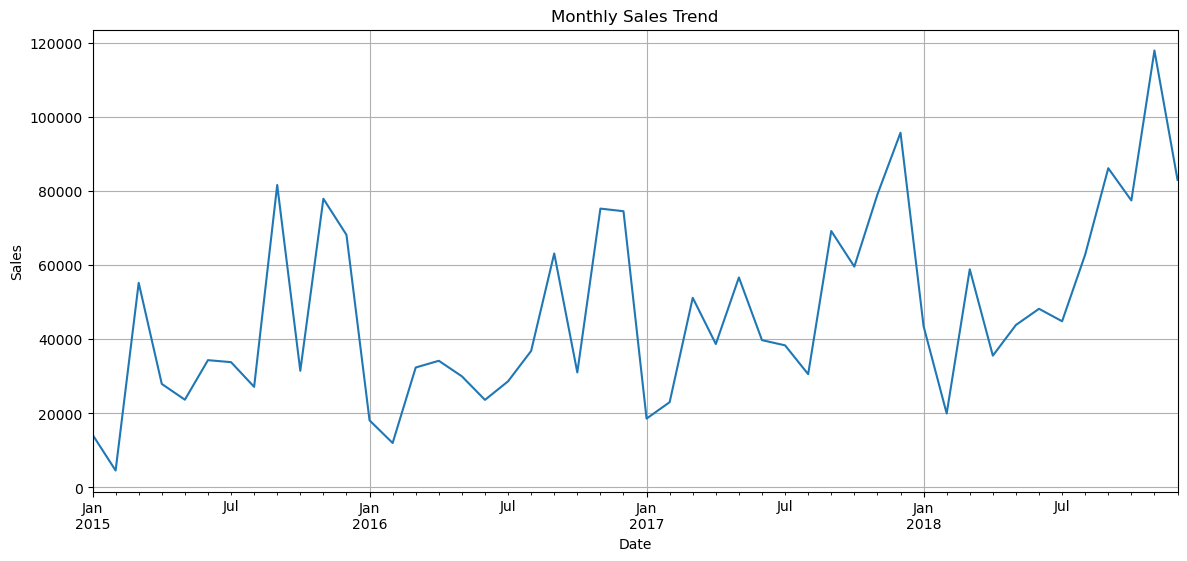

In [35]:
plt.figure(figsize=(14,6))
monthly_sales.plot()
plt.title("Monthly Sales Trend")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.grid(True)
plt.savefig("charts/monthly_sales_trend.png")
plt.show()

### Observation

The line chart provides a clear overview of how monthly sales have changed over the four-year period. Long-term growth, seasonal peaks, and sudden fluctuations become easier to identify.

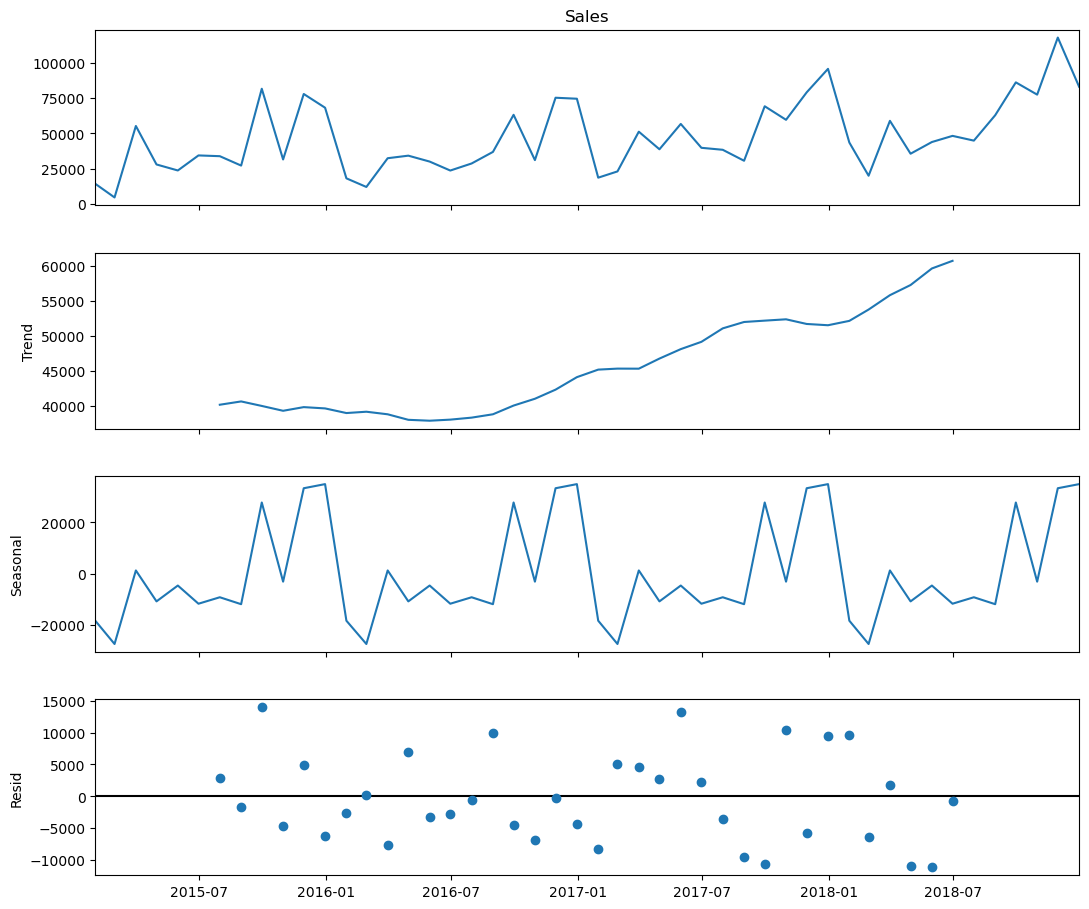

In [36]:
from statsmodels.tsa.seasonal import seasonal_decompose
decomposition = seasonal_decompose(
    monthly_sales,
    model="additive",
    period=12
)
fig = decomposition.plot()
fig.set_size_inches(12,10)
plt.savefig("charts/decomposition.png")
plt.show()

## Understanding the Decomposition

The decomposition separates the sales data into four components:

- **Observed:** Original monthly sales data.
- **Trend:** Long-term direction of sales.
- **Seasonal:** Repeating yearly patterns.
- **Residual:** Random variations that cannot be explained by trend or seasonality.

### Observations

- The trend component shows whether sales generally increase or decrease over time.
- The seasonal component reveals recurring sales patterns across different months.
- The residual component highlights unexpected spikes or drops that may represent promotions, holidays, or unusual business events.

In [37]:
from statsmodels.tsa.stattools import adfuller
result = adfuller(monthly_sales)
print("ADF Statistic :", result[0])
print("P-Value :", result[1])

ADF Statistic : -4.416136761430769
P-Value : 0.00027791039276670623


## What is Stationarity?

A time series is called **stationary** when its average value and variation remain relatively stable over time.

Most forecasting models perform better when the data is stationary because they assume that historical patterns remain consistent.

In [38]:
if result[1] < 0.05:
    print("The time series is stationary.")
else:
    print("The time series is NOT stationary.")

The time series is stationary.


In [39]:
monthly_sales_diff = monthly_sales.diff().dropna()
monthly_sales_diff.head()

Order Date
2015-02-28    -9685.8150
2015-03-31    50685.9050
2015-04-30   -27298.9420
2015-05-31    -4262.5520
2015-06-30    10678.6326
Freq: ME, Name: Sales, dtype: float64

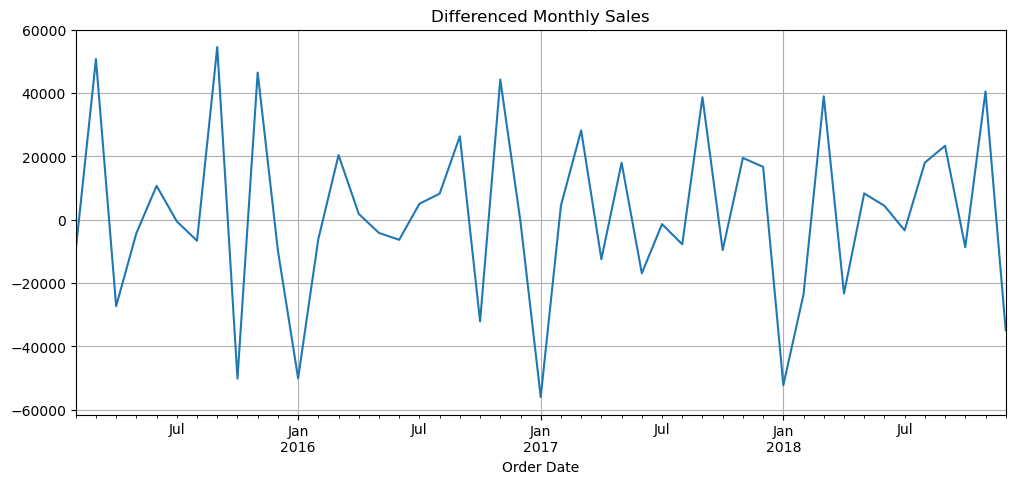

In [40]:
plt.figure(figsize=(12,5))
monthly_sales_diff.plot()
plt.title("Differenced Monthly Sales")
plt.grid(True)
plt.savefig("charts/differenced_sales.png")
plt.show()

In [41]:
result_diff = adfuller(monthly_sales_diff)
print("ADF Statistic :", result_diff[0])
print("P-Value :", result_diff[1])
if result_diff[1] < 0.05:
    print("The differenced series is now stationary.")
else:
    print("The differenced series is still not stationary.")

ADF Statistic : -8.72706183035328
P-Value : 3.2669175472794505e-14
The differenced series is now stationary.


### Summary of Task 2

The sales data was analyzed as a time series to understand its behavior over time. Monthly sales trends, seasonal decomposition, and stationarity testing were performed. If the original series was not stationary, differencing was applied to stabilize it. These steps prepare the data for forecasting models such as SARIMA, Prophet, and XGBoost.

# Task 3 – Sales Forecasting

The objective of this task is to forecast future sales using three different forecasting techniques. Each model is trained on historical monthly sales data and evaluated using common forecasting metrics. The model with the lowest prediction error will be considered the best-performing model.

In [42]:
# Split Monthly Sales into Train and Test Sets
train = monthly_sales[:-12]
test = monthly_sales[-12:]
print("Training Months:", len(train))
print("Testing Months :", len(test))

Training Months: 36
Testing Months : 12


We use the first part of the time series for training and reserve the last 12 months for testing. This allows us to compare the forecast with actual sales values.

In [49]:
# SARIMAX
from statsmodels.tsa.statespace.sarimax import SARIMAX
sarima = SARIMAX(
    train,
    order=(1,1,1),
    seasonal_order=(1,1,1,12)
)
sarima_model = sarima.fit()
sarima_forecast = sarima_model.forecast(steps=12)

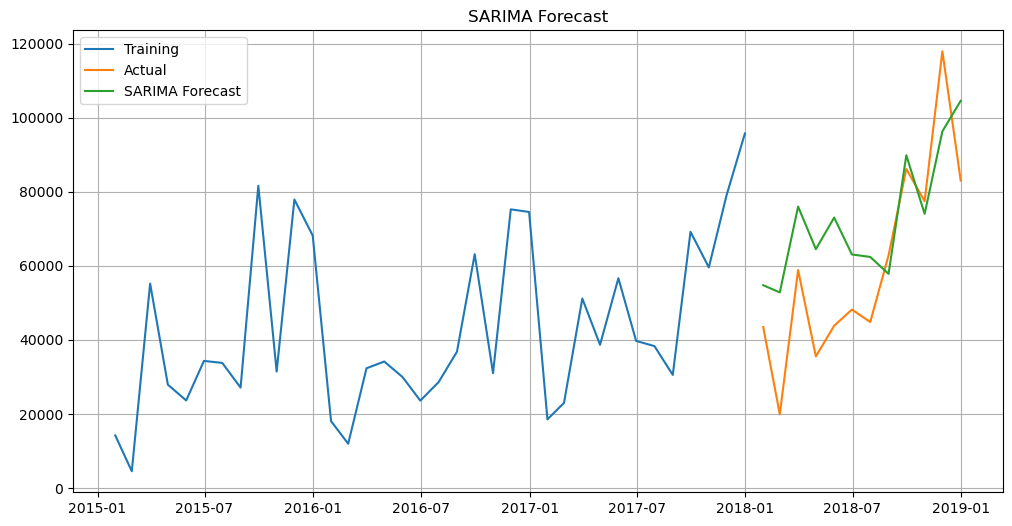

In [50]:
# SARIMAX plot
plt.figure(figsize=(12,6))
plt.plot(train.index, train, label="Training")
plt.plot(test.index, test, label="Actual")
plt.plot(test.index, sarima_forecast, label="SARIMA Forecast")
plt.title("SARIMA Forecast")
plt.legend()
plt.grid(True)
plt.savefig("charts/sarima_forecast.png")
plt.show()

In [51]:
# Prophet
from prophet import Prophet
prophet_df = monthly_sales.reset_index()
prophet_df.columns = ["ds","y"]
train_prophet = prophet_df[:-12]
model = Prophet()
model.fit(train_prophet)
future = model.make_future_dataframe(periods=12, freq="M")
forecast = model.predict(future)
prophet_forecast = forecast.tail(12)["yhat"].values

20:52:25 - cmdstanpy - INFO - Chain [1] start processing
20:52:26 - cmdstanpy - INFO - Chain [1] done processing


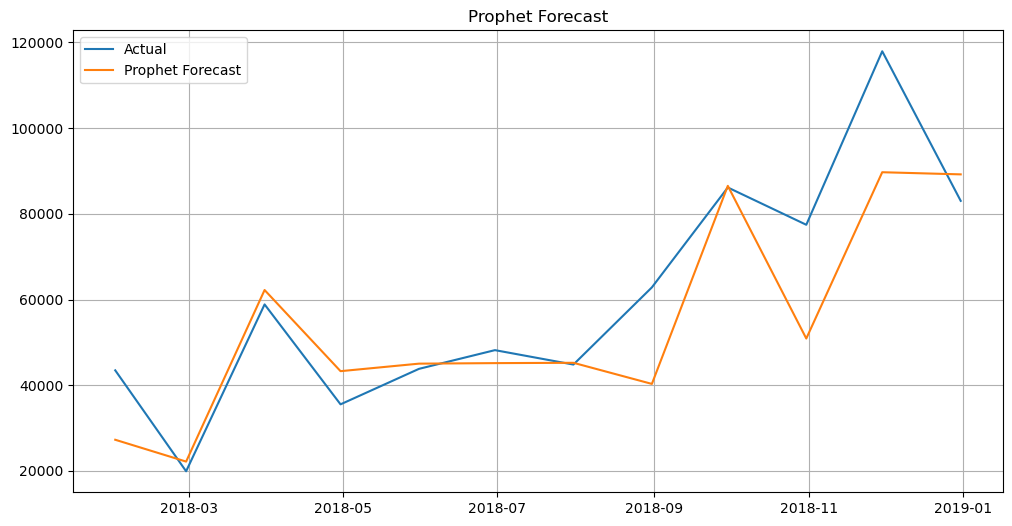

In [52]:
# Prophet plot
plt.figure(figsize=(12,6))
plt.plot(test.index, test.values, label="Actual")
plt.plot(test.index, prophet_forecast, label="Prophet Forecast")
plt.title("Prophet Forecast")
plt.legend()
plt.grid(True)
plt.savefig("charts/prophet_forecast.png")
plt.show()

In [53]:
# xgboost
from xgboost import XGBRegressor
xgb_df = monthly_sales.reset_index()
xgb_df["Month"] = xgb_df["Order Date"].dt.month
xgb_df["Year"] = xgb_df["Order Date"].dt.year
X = xgb_df[["Year","Month"]]
y = xgb_df["Sales"]
X_train = X[:-12]
X_test = X[-12:]
y_train = y[:-12]
y_test = y[-12:]
xgb = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    random_state=42
)
xgb.fit(X_train,y_train)
xgb_forecast = xgb.predict(X_test)

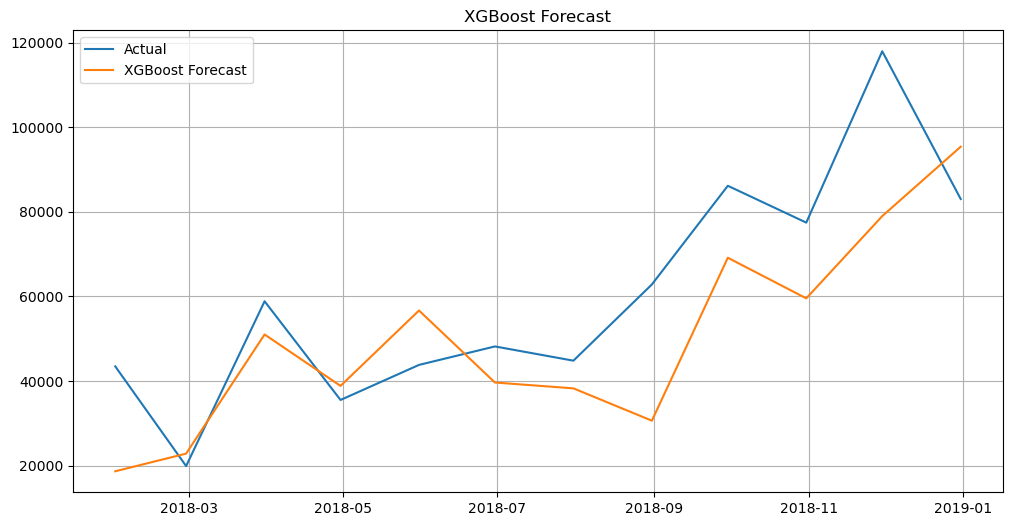

In [54]:
# xgboost plot
plt.figure(figsize=(12,6))
plt.plot(test.index,test.values,label="Actual")
plt.plot(test.index,xgb_forecast,label="XGBoost Forecast")
plt.title("XGBoost Forecast")
plt.legend()
plt.grid(True)
plt.savefig("charts/xgboost_forecast.png")
plt.show()

The three forecasting models have now generated predictions for the final twelve months. The next step is to compare their prediction accuracy using evaluation metrics.

In [55]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
import numpy as np
def mape(actual,pred):
    return np.mean(np.abs((actual-pred)/actual))*100

taking values for comparison

In [56]:
sarima_mae = mean_absolute_error(test,sarima_forecast)
sarima_rmse = np.sqrt(mean_squared_error(test,sarima_forecast))
sarima_mape = mape(test.values,sarima_forecast.values)

In [57]:
prophet_mae = mean_absolute_error(test,prophet_forecast)
prophet_rmse = np.sqrt(mean_squared_error(test,prophet_forecast))
prophet_mape = mape(test.values,prophet_forecast)

In [58]:
xgb_mae = mean_absolute_error(test,xgb_forecast)
xgb_rmse = np.sqrt(mean_squared_error(test,xgb_forecast))
xgb_mape = mape(test.values,xgb_forecast)

In [59]:
comparison = pd.DataFrame({
    "Model":[
        "SARIMA",
        "Prophet",
        "XGBoost"
    ],
    "MAE":[
        sarima_mae,
        prophet_mae,
        xgb_mae
    ],
    "RMSE":[
        sarima_rmse,
        prophet_rmse,
        xgb_rmse
    ],
    "MAPE":[
        sarima_mape,
        prophet_mape,
        xgb_mape
    ]
})
comparison

,Model,MAE,RMSE,MAPE
0,SARIMA,17267.924313,19805.389590,41.612945
1,Prophet,9839.837362,14133.075502,15.668720
2,XGBoost,15434.356388,18911.719573,24.838051


In [60]:
best_model = comparison.sort_values(
    by="RMSE"
).iloc[0]
print("Best Forecasting Model")
print(best_model)

Best Forecasting Model
Model         Prophet
MAE       9839.837362
RMSE     14133.075502
MAPE         15.66872
Name: 1, dtype: object


### Observation

The comparison table summarizes the performance of all three forecasting models. The model with the lowest MAE, RMSE, and MAPE values provides the most accurate sales predictions and will be selected for future forecasting.

# Task 4 – Category & Region Forecasting

Overall sales forecasting provides a general business outlook. However, forecasting sales for individual product categories and regions helps managers make more informed inventory, marketing, and logistics decisions.

In this task, we analyze sales trends across different categories and regions to identify which segments contribute the most to business growth.

In [61]:
# Category-wise Sales
category_sales = df.groupby("Category")["Sales"].sum().sort_values(ascending=False)
category_sales

Category
Technology         827455.8730
Furniture          728658.5757
Office Supplies    705422.3340
Name: Sales, dtype: float64

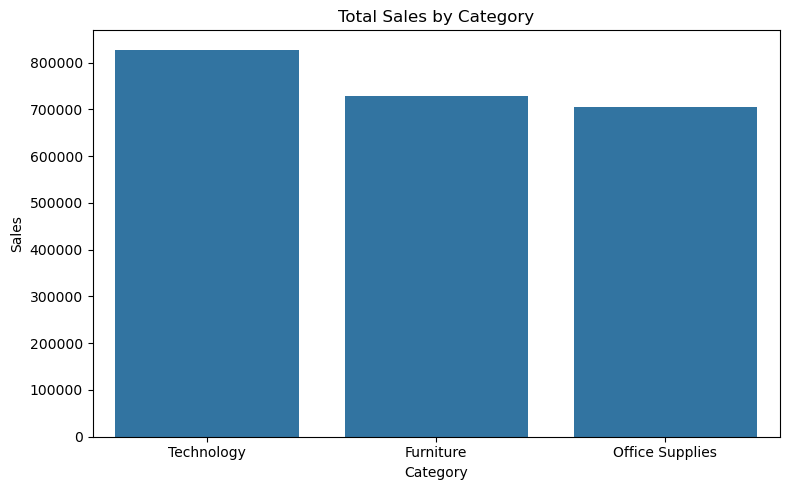

In [62]:
plt.figure(figsize=(8,5))
sns.barplot(
    x=category_sales.index,
    y=category_sales.values
)
plt.title("Total Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales")
plt.tight_layout()
plt.savefig("charts/category_sales.png")
plt.show()

### Observation

This chart shows which product category generates the highest revenue. Categories with consistently higher sales should receive priority during inventory planning and promotional campaigns.

In [63]:
region_sales = df.groupby("Region")["Sales"].sum().sort_values(ascending=False)
region_sales

Region
West       710219.6845
East       669518.7260
Central    492646.9132
South      389151.4590
Name: Sales, dtype: float64

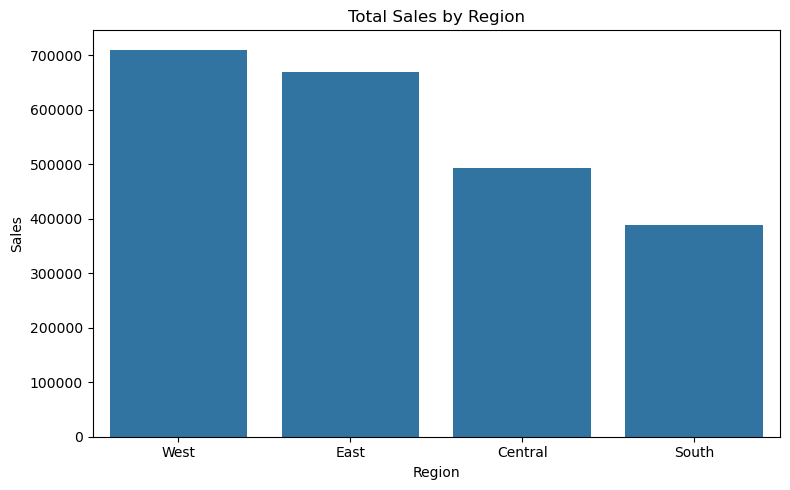

In [64]:
plt.figure(figsize=(8,5))
sns.barplot(
    x=region_sales.index,
    y=region_sales.values
)
plt.title("Total Sales by Region")
plt.xlabel("Region")
plt.ylabel("Sales")
plt.tight_layout()
plt.savefig("charts/region_sales.png")
plt.show()

### Observation

Regional sales analysis helps businesses identify their strongest and weakest markets. High-performing regions may require larger inventory allocation, while lower-performing regions may benefit from targeted marketing strategies.

In [65]:
category_monthly = df.groupby(
    ["Order Date","Category"]
)["Sales"].sum().reset_index()
category_monthly.head()

,Order Date,Category,Sales
0,2015-01-03,Office Supplies,16.448
1,2015-01-04,Office Supplies,288.060
2,2015-01-05,Office Supplies,19.536
3,2015-01-06,Furniture,2573.820
4,2015-01-06,Office Supplies,685.340


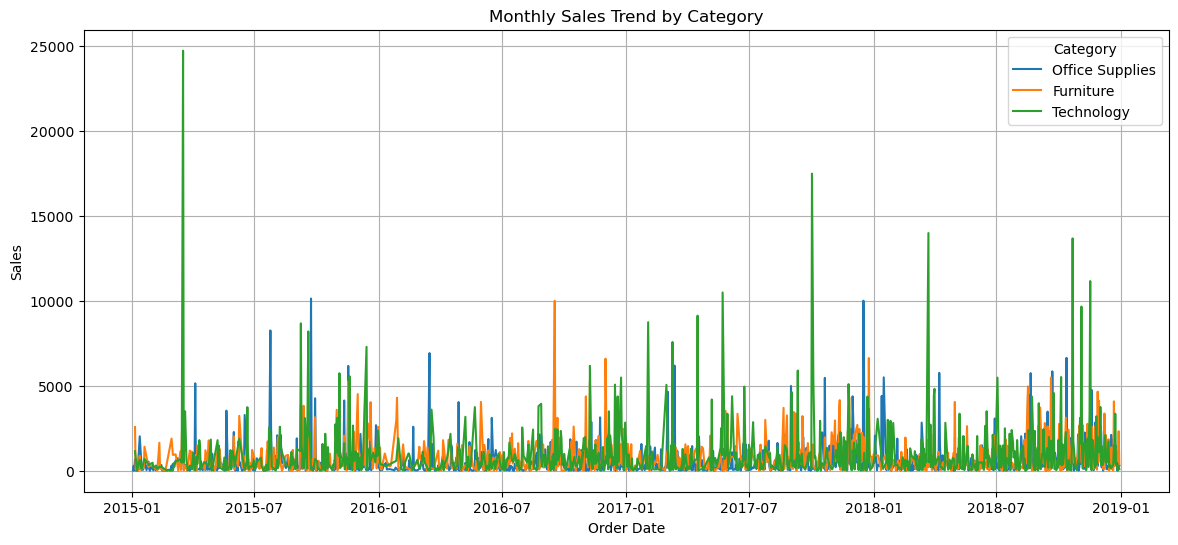

In [66]:
plt.figure(figsize=(14,6))
sns.lineplot(
    data=category_monthly,
    x="Order Date",
    y="Sales",
    hue="Category"
)
plt.title("Monthly Sales Trend by Category")
plt.grid(True)
plt.savefig("charts/category_trend.png")
plt.show()

### Observation

The monthly trend allows us to compare how sales change over time for different product categories. This can reveal seasonal demand patterns and identify categories with steady or fluctuating performance.

# Task 5 – Sales Anomaly Detection

Anomaly detection is used to identify unusual sales values that significantly differ from normal business patterns. These unusual observations may indicate successful promotions, seasonal demand, inventory shortages, or possible data entry errors.

Two anomaly detection techniques are applied:

- Z-Score Method
- Isolation Forest

In [67]:
from scipy.stats import zscore

In [68]:
# Calculate Z-Scores
df["Z_Score"] = zscore(df["Sales"])
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Sales,Year,Month,Month Name,Quarter,Week,Day,Season,Shipping Days,Z_Score
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,261.9600,2017,11,November,4,45,Wednesday,Autumn,3,0.049776
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,731.9400,2017,11,November,4,45,Wednesday,Autumn,3,0.799801
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,14.6200,2017,6,June,2,24,Monday,Monsoon,4,-0.344944
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,957.5775,2016,10,October,4,41,Tuesday,Autumn,7,1.159887
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,22.3680,2016,10,October,4,41,Tuesday,Autumn,7,-0.332580


In [69]:
# Detect Outliers
z_outliers = df[abs(df["Z_Score"]) > 3]
print("Number of Outliers:", len(z_outliers))
z_outliers.head()

Number of Outliers: 123


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Sales,Year,Month,Month Name,Quarter,Week,Day,Season,Shipping Days,Z_Score
27,28,US-2016-150630,2016-09-17,2016-09-21,Standard Class,TB-21520,Tracy Blumstein,Consumer,United States,Philadelphia,...,3083.430,2016,9,September,3,37,Saturday,Autumn,4,4.552458
165,166,CA-2015-139892,2015-09-08,2015-09-12,Standard Class,BM-11140,Becky Martin,Consumer,United States,San Antonio,...,8159.952,2015,9,September,3,37,Tuesday,Autumn,4,12.653896
251,252,CA-2017-145625,2017-09-11,2017-09-17,Standard Class,KC-16540,Kelly Collister,Consumer,United States,San Diego,...,3347.370,2017,9,September,3,37,Monday,Autumn,6,4.973671
262,263,US-2015-106992,2015-09-19,2015-09-21,Second Class,SB-20290,Sean Braxton,Corporate,United States,Houston,...,3059.982,2015,9,September,3,38,Saturday,Autumn,2,4.515038
263,264,US-2015-106992,2015-09-19,2015-09-21,Second Class,SB-20290,Sean Braxton,Corporate,United States,Houston,...,2519.958,2015,9,September,3,38,Saturday,Autumn,2,3.653234


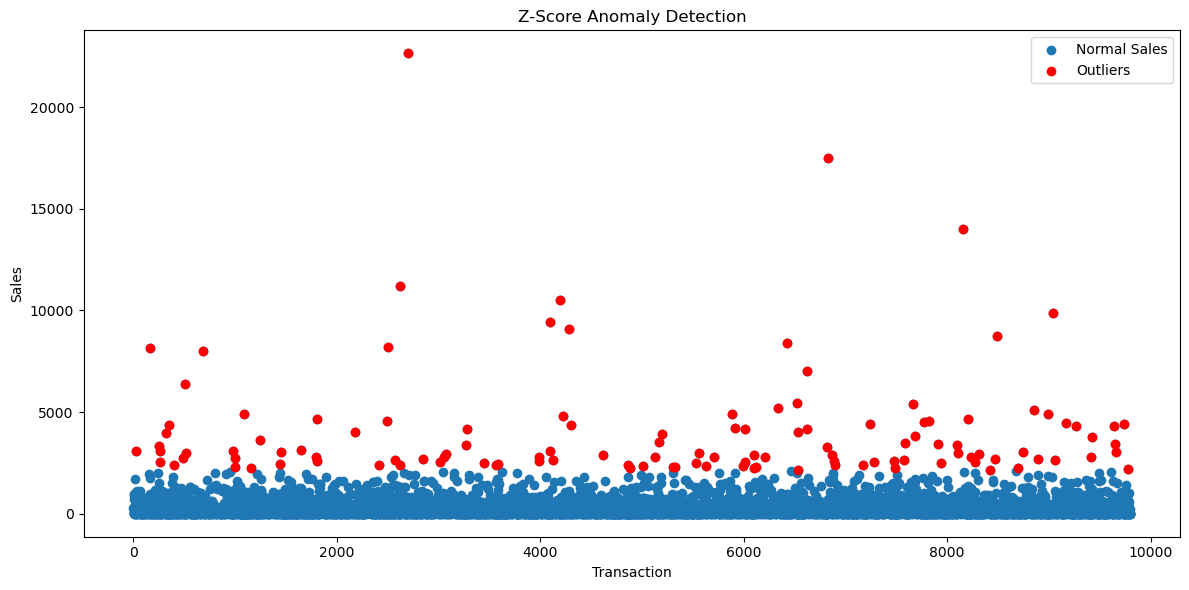

In [70]:
plt.figure(figsize=(12,6))
plt.scatter(
    df.index,
    df["Sales"],
    label="Normal Sales"
)
plt.scatter(
    z_outliers.index,
    z_outliers["Sales"],
    color="red",
    label="Outliers"
)
plt.title("Z-Score Anomaly Detection")
plt.xlabel("Transaction")
plt.ylabel("Sales")
plt.legend()
plt.tight_layout()
plt.savefig("charts/zscore_outliers.png")
plt.show()

### Observation

The highlighted points represent unusually high or low sales compared to the majority of transactions. These observations should be investigated further before making business decisions.

In [71]:
from sklearn.ensemble import IsolationForest

In [72]:
iso = IsolationForest(
    contamination=0.02,
    random_state=42
)
df["Anomaly"] = iso.fit_predict(df[["Sales"]])
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Year,Month,Month Name,Quarter,Week,Day,Season,Shipping Days,Z_Score,Anomaly
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,2017,11,November,4,45,Wednesday,Autumn,3,0.049776,1
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,2017,11,November,4,45,Wednesday,Autumn,3,0.799801,1
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,2017,6,June,2,24,Monday,Monsoon,4,-0.344944,1
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,2016,10,October,4,41,Tuesday,Autumn,7,1.159887,1
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,2016,10,October,4,41,Tuesday,Autumn,7,-0.332580,1


In [73]:
anomalies = df[df["Anomaly"]==-1]
print("Anomalies Found:",len(anomalies))

Anomalies Found: 196


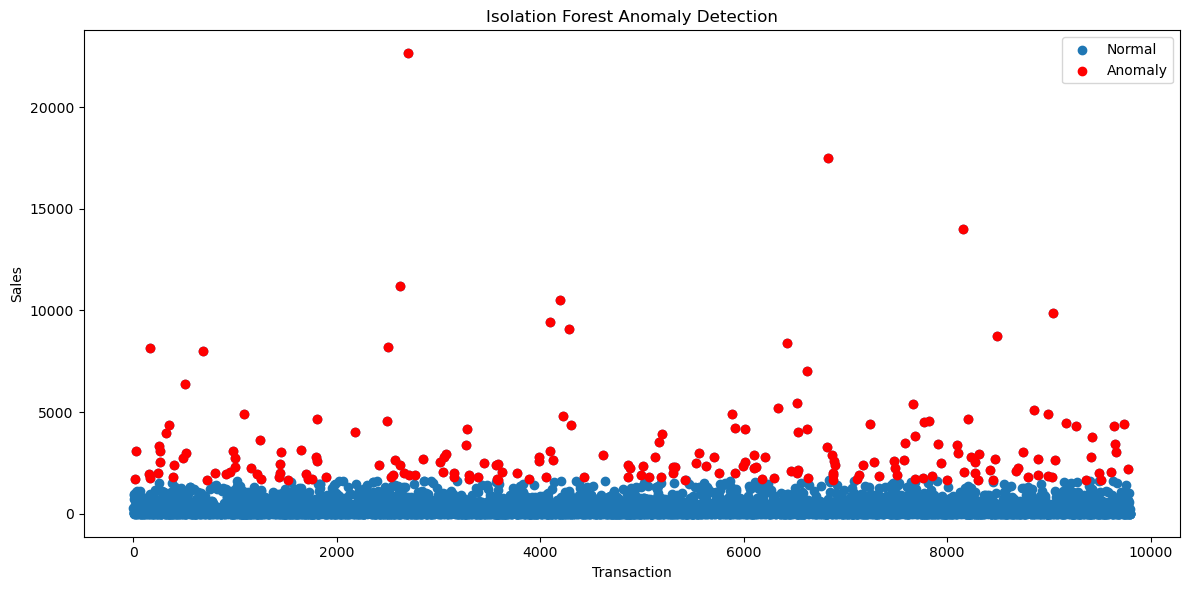

In [74]:
plt.figure(figsize=(12,6))
plt.scatter(
    df.index,
    df["Sales"],
    label="Normal"
)
plt.scatter(
    anomalies.index,
    anomalies["Sales"],
    color="red",
    label="Anomaly"
)
plt.title("Isolation Forest Anomaly Detection")
plt.xlabel("Transaction")
plt.ylabel("Sales")
plt.legend()
plt.tight_layout()
plt.savefig("charts/isolation_forest.png")
plt.show()

### Observation

Isolation Forest identifies transactions that are significantly different from the majority of sales records. Unlike the Z-Score method, Isolation Forest can detect anomalies without assuming that the data follows a normal distribution.

In [75]:
comparison = pd.DataFrame({
    "Method":[
        "Z-Score",
        "Isolation Forest"
    ],
    "Detected Outliers":[
        len(z_outliers),
        len(anomalies)
    ]
})
comparison

,Method,Detected Outliers
0,Z-Score,123
1,Isolation Forest,196


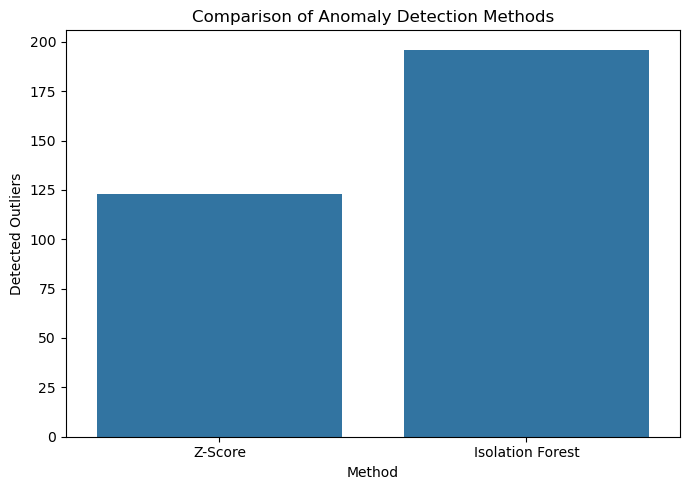

In [76]:
plt.figure(figsize=(7,5))
sns.barplot(
    data=comparison,
    x="Method",
    y="Detected Outliers"
)
plt.title("Comparison of Anomaly Detection Methods")
plt.tight_layout()
plt.savefig("charts/anomaly_comparison.png")
plt.show()

In this section, sales performance was analyzed across different product categories and regions. Category-level trends provided insight into customer demand, while regional analysis highlighted geographical sales performance.

Two anomaly detection techniques were also applied to identify unusual sales transactions. These methods can help businesses detect unexpected demand spikes, promotional effects, or possible data quality issues before making operational decisions.

# Task 6 – Product Segmentation using K-Means Clustering

Different products contribute differently to sales. Grouping products into similar clusters helps businesses understand customer demand, improve inventory planning, and develop better marketing strategies.

In this task, K-Means Clustering is used to group products based on their sales performance.

In [77]:
product_sales = df.groupby("Product Name")["Sales"].sum().reset_index()
product_sales.head()

,Product Name,Sales
0,"""While you Were Out"" Message Book, One Form pe...",25.228
1,"#10 Gummed Flap White Envelopes, 100/Box",41.300
2,#10 Self-Seal White Envelopes,108.682
3,"#10 White Business Envelopes,4 1/8 x 9 1/2",379.214
4,"#10- 4 1/8"" x 9 1/2"" Recycled Envelopes",286.672


In [78]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaled_data = scaler.fit_transform(product_sales[["Sales"]])

In [79]:
from sklearn.cluster import KMeans
inertia = []
for i in range(1,11):
    model = KMeans(
        n_clusters=i,
        random_state=42
    )
    model.fit(scaled_data)
    inertia.append(model.inertia_)

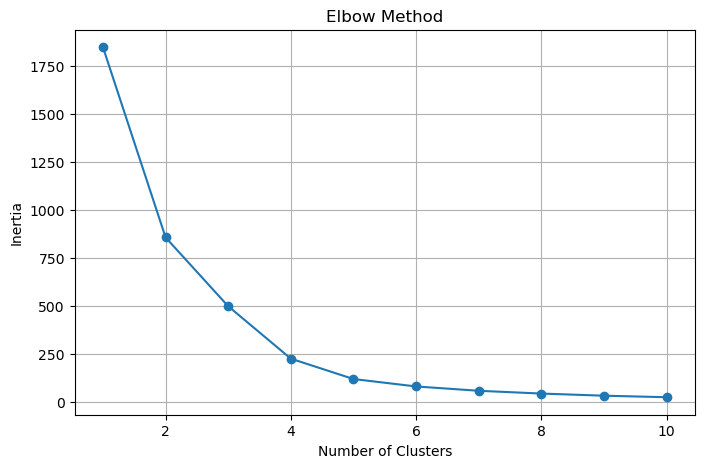

In [80]:
plt.figure(figsize=(8,5))
plt.plot(
    range(1,11),
    inertia,
    marker="o"
)
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.grid(True)
plt.savefig("charts/elbow_method.png")
plt.show()

### Observation

The elbow point indicates the most suitable number of clusters for grouping products.

In [81]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42
)
product_sales["Cluster"] = kmeans.fit_predict(
    scaled_data
)
product_sales.head()

,Product Name,Sales,Cluster
0,"""While you Were Out"" Message Book, One Form pe...",25.228,0
1,"#10 Gummed Flap White Envelopes, 100/Box",41.300,0
2,#10 Self-Seal White Envelopes,108.682,0
3,"#10 White Business Envelopes,4 1/8 x 9 1/2",379.214,0
4,"#10- 4 1/8"" x 9 1/2"" Recycled Envelopes",286.672,0


In [85]:
product_sales = df.groupby("Product Name")["Sales"].sum().reset_index()
scaler = StandardScaler()
scaled_data = scaler.fit_transform(product_sales[["Sales"]])
pca = PCA(n_components=2)
# Create product-level features
product_sales = df.groupby("Product Name").agg(
    Total_Sales=("Sales", "sum"),
    Average_Sale=("Sales", "mean"),
    Sales_Volatility=("Sales", "std"),
    Order_Count=("Sales", "count")
).reset_index()
# Replace NaN values (for products with only one order)
product_sales = product_sales.fillna(0)
product_sales.head()

,Product Name,Total_Sales,Average_Sale,Sales_Volatility,Order_Count
0,"""While you Were Out"" Message Book, One Form pe...",25.228,8.409333,0.856788,3
1,"#10 Gummed Flap White Envelopes, 100/Box",41.300,10.325000,4.344687,4
2,#10 Self-Seal White Envelopes,108.682,27.170500,26.884197,4
3,"#10 White Business Envelopes,4 1/8 x 9 1/2",379.214,63.202333,39.514094,6
4,"#10- 4 1/8"" x 9 1/2"" Recycled Envelopes",286.672,28.667200,15.287646,10


In [86]:
from sklearn.preprocessing import StandardScaler
features = product_sales[
    ["Total_Sales", "Average_Sale", "Sales_Volatility", "Order_Count"]
]
scaler = StandardScaler()
scaled_data = scaler.fit_transform(features)

In [87]:
from sklearn.cluster import KMeans
kmeans = KMeans(
    n_clusters=3,
    random_state=42
)
product_sales["Cluster"] = kmeans.fit_predict(scaled_data)
product_sales.head()

,Product Name,Total_Sales,Average_Sale,Sales_Volatility,Order_Count,Cluster
0,"""While you Were Out"" Message Book, One Form pe...",25.228,8.409333,0.856788,3,0
1,"#10 Gummed Flap White Envelopes, 100/Box",41.300,10.325000,4.344687,4,0
2,#10 Self-Seal White Envelopes,108.682,27.170500,26.884197,4,0
3,"#10 White Business Envelopes,4 1/8 x 9 1/2",379.214,63.202333,39.514094,6,0
4,"#10- 4 1/8"" x 9 1/2"" Recycled Envelopes",286.672,28.667200,15.287646,10,0


In [88]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
pca_data = pca.fit_transform(scaled_data)
product_sales["PCA1"] = pca_data[:, 0]
product_sales["PCA2"] = pca_data[:, 1]

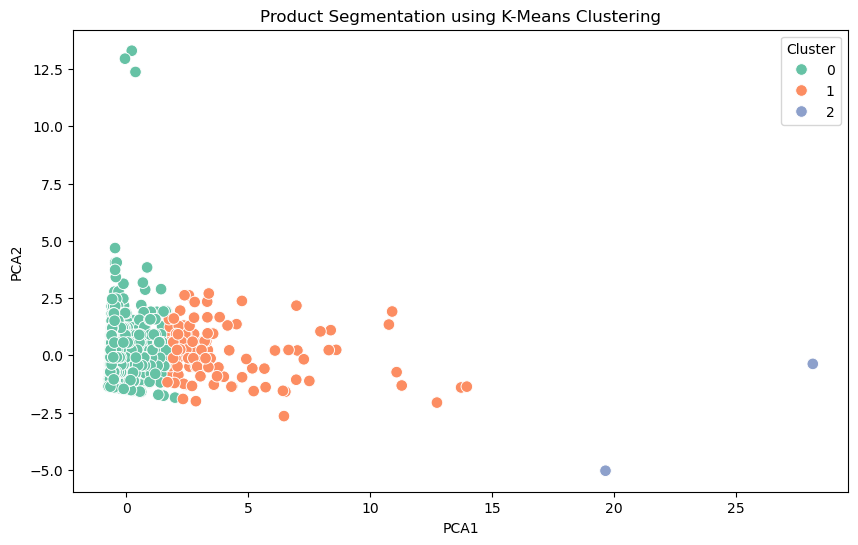

In [89]:
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=product_sales,
    x="PCA1",
    y="PCA2",
    hue="Cluster",
    palette="Set2",
    s=70
)
plt.title("Product Segmentation using K-Means Clustering")
plt.savefig("charts/product_clusters.png")
plt.show()

### Observation

Products belonging to the same cluster exhibit similar sales characteristics. This information can help businesses classify products into high-demand, medium-demand, and low-demand groups.

# Task 7 – Streamlit Dashboard

To make the analysis interactive, a Streamlit dashboard was developed. The dashboard allows managers to explore sales trends, forecasting results, anomaly detection, and product clusters without writing any code.

# Task 8 – Executive Business Summary

This project demonstrates how historical sales data can be transformed into valuable business insights through forecasting and machine learning techniques.

The forecasting models help estimate future demand, while anomaly detection identifies unusual sales patterns that may require further investigation. Product clustering groups similar products together, enabling better inventory planning and targeted marketing strategies.

The interactive dashboard makes these insights easily accessible to business managers, allowing them to monitor sales performance and make informed decisions without requiring technical knowledge.

# Conclusion

This project successfully implemented an end-to-end sales forecasting and demand intelligence system using Python and machine learning techniques.

Historical sales data was cleaned, analyzed, and transformed into meaningful business insights through forecasting, anomaly detection, and clustering. The results demonstrate how data-driven decision-making can improve inventory management, demand planning, and overall business performance.

The Streamlit dashboard further enhances usability by providing an interactive platform for exploring sales trends and forecasts.